# PART 2 - PV Systems Modeling with Python

Welcome to the tutorial on **PV Systems modeling with Python** at the University of Alaska Fairbanks (UAF). This tutorial will give an interactive introduction to how to model photovoltaic (PV) system energy yield using the open-source software [pvlib-python](https://pvlib-python.readthedocs.io/en/latest/). The tutorial will focus specifically on high latitude systems and datasets.

It is recommended to first complete Part 1 of the tutorial, which gives an introduction to Google Colab and how to retrieve irradiance data using pvlib. Part 1 can be found [here](https://colab.research.google.com/github/PV-Tutorials/2026_pvlib_uaf/blob/main/pvlib-introduction-part-1.ipynb).

We will be modeling the energy yield of a fixed-tilt PV system with bifacial modules. The specific system is the planned expansion of the PV system in Kotzebue, Alaska.

![Kotzebue PV system](https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fwww.energy.gov%2Fsites%2Fdefault%2Ffiles%2F2022-09%2FKotzebue%2520solar%2520array%2520with%2520turbines_2from%2520Amanda%2520Byrd_1.jpg&f=1&nofb=1&ipt=2200077880c7504f382525596138373822a623b965601c8d0ed14203f0dce674)

*Photo credit: Department of Energy.*


## Plant specification

You can assume the following plant specifications:

**General information**
* Location: [Kotzebue, Alaska, USA](https://maps.app.goo.gl/gmWnEhB8vSx71isp9)
* Planned start year: 2027

**Plant layout and configuration**
* Mounting: fixed-tilt racks
* Orientation: south facing (azimuth: 180 degrees)
* Module configuration: one-in-portrait (1P)
* Tilt: 40 degrees (_estimate_)
* Pitch (row-to-row distance): 15 m (~50 ft)
* Center module height: 1.5 m (_estimate_)

**Modules**
* Total capacity: 625 kW AC / 800 kW DC
* Module nameplate capacity: ~590 W DC
* No. of modules: 1357
* Technology: bifacial half-cut TOPCon (crystalline Si)
* Manufacturer: Talesun
* Module model: BIPRO TM7G72M ([datasheet](https://www.talesun.com/en/wp-content/uploads/2025/07/585-605-BIPRO_TM7G72M_16BB-Enhanced_12_20250515_EN.pdf))


**Inverter**
* Type: string inverter
* Manufacturer: Solectria
* Model: XGI 1500 VDC ([datasheet](https://www.solectria.com//site/assets/files/2522/solectria_xgi_1500-166.pdf))
* Capactiy: 125 kW AC

## Step 1: Install pvlib

First, we need to get pvlib installed in the Colab environment.  Select the code cell below (left click) and execute it (shift+enter) to automatically download and install pvlib:

**Note that we will be using a pre-release version of pvlib (alpha version) in order to use the NSRDB Polar dataset, which first will be officially added in the upcoming release aimed for September 2026.**

In [ ]:
!pip install pvlib==0.15.3-alpha.1

In [1]:
# Import libraries
import pvlib
import pandas as pd
import matplotlib.pyplot as plt

## Step 2: Irradiance data
In this step, you need to download irradiance data for the site. We will be using the recently released Arctic-specific dataset: [NSRDB Polar](https://pvlib-python.readthedocs.io/en/latest/reference/generated/pvlib.iotools.get_nsrdb_psm4_polar_tmy.html). You can read more about the dataset [here](https://nsrdb.nlr.gov/data-sets/polar-data).

👉 Remember that you need to update the latitude and longitude for the actual PV site. For the API key you can use ``"DEMO_KEY"`` and for the ``year`` put ``"tmy"`` to get a typical meteorological year.

In [ ]:
# retrieve irradiance data
data, meta = pvlib.iotools.get_nsrdb_psm4_polar_tmy(
    # Action: fill in the necessary parameters
    )

# No need to edit this line: it just makes the year consistent as TMY data is sampled from multiple years
data.index = data.index.map(lambda d: d.replace(year=2025))

data.head()

,temp_air,relative_humidity,ghi,dni,dhi,IR(h),wind_speed,wind_direction,pressure
time(UTC),,,,,,,,,
1990-01-01 00:30:00+00:00,15.39,32.34,0.75,0.0,0.75,274.97,2.78,64.0,77870.0
1990-01-01 01:30:00+00:00,14.89,31.25,0.00,0.0,0.00,269.59,2.56,76.0,77940.0
1990-01-01 02:30:00+00:00,14.38,30.17,0.00,0.0,0.00,264.20,2.33,85.0,77980.0
1990-01-01 03:30:00+00:00,13.88,29.08,0.00,0.0,0.00,258.82,2.11,97.0,78030.0
1990-01-01 04:30:00+00:00,13.37,28.00,0.00,0.0,0.00,253.44,1.88,116.0,78070.0


## Step 3: Albedo
Albedo is a measure of how well the ground reflects irradiance. The returned dataset contains a time series of albeo estimate, which ranges from 0.8 for snow covered ground to 0.1 for bare soil.

👉 Plot the albedo below and see how it changes throughout the year. Does it match with what you would expect?

In [ ]:
# Write your code here


## Step 4: Calculate solar position
This step was covered in Part 1 of the tutorial.


In [ ]:
location = pvlib.location.Location(latitude=meta["latitude"], longitude=meta["longitude"])

solar_position = location.get_solarposition(data.index)

## Step 5: Calculate plane of array irradiance
The irradiance data we obtained contains the three standard components:
- global horizontal irradiance (GHI)
- diffuse horizontal irradiance (DHI)
- direct normal irradiance (DNI)

However, to determine PV generation, we need to know the incident irradiance on the module surface, which is denoted as **plane of array (POA) irradiance**. Since the panels are bifcial, we need to estimate the irradiance on both the front and rear side.

To do this, we will be using pvlib's [infinite sheds bifacial model](https://pvlib-python.readthedocs.io/en/stable/user_guide/modeling_topics/bifacial.html#infinite-sheds), which is based on view factors and assumes the PV system comprises of parallel, evenly spaced rows on a level, horizontal surface. The function is called ``pvlib.bifacial.infinite_sheds.get_irradiance`` ([link to documentation](https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.bifacial.infinite_sheds.get_irradiance.html)).

👉 **Can you use the infinite sheds model to calculate front- and rear-side irradiance?**

In [ ]:
# Write your code here to calculate plane of array irradiance
bifaciality =   # [ ] bifaciality factor, see datasheet
surface_tilt =  # [deg] fixed tilt angle
surface_azimuth =   # [deg] south-facing

height =   # [m] height of the module center above the ground
pitch =   # [m] center-to-center tracker spacing in the horizontal dimension
module_length =   # [m] see datasheet
gcr = module_length / pitch


dni_extra = pvlib.irradiance.get_extra_radiation(data.index)

poa_irradiance = pvlib.bifacial.infinite_sheds.get_irradiance(
    surface_tilt=surface_tilt,
    surface_azimuth=surface_azimuth,
    solar_zenith=solar_position['apparent_zenith'],
    solar_azimuth=solar_position['azimuth'],
    gcr=gcr,
    height=height,
    pitch=pitch,
    ghi=data['ghi'],
    dhi=data['dhi'],
    dni=data['dni'],
    albedo=data['albedo'],
    bifaciality=bifaciality,
)

# Print five first rows
poa_irradiance.head()

,poa_front,poa_front_direct,poa_front_diffuse,poa_front_ground_diffuse,poa_front_sky_diffuse,shaded_fraction_front,poa_back,poa_back_direct,poa_back_diffuse,poa_back_ground_diffuse,poa_back_sky_diffuse,shaded_fraction_back,poa_global
time(UTC),,,,,,,,,,,,,
1990-01-01 13:30:00+00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000
1990-01-01 14:30:00+00:00,355.704767,302.212508,53.492259,0.660921,52.831338,0.0,12.094046,0.0,12.094046,7.331206,4.762840,0.0,365.186499
1990-01-01 15:30:00+00:00,484.525601,376.096883,108.428717,6.254276,102.174441,0.0,51.177025,0.0,51.177025,21.620541,29.556484,0.0,524.648388
1990-01-01 16:30:00+00:00,450.986776,280.648126,170.338650,5.042048,165.296602,0.0,60.486802,0.0,60.486802,39.256167,21.230635,0.0,498.408428
1990-01-01 17:30:00+00:00,562.735581,359.918756,202.816826,2.458543,200.358283,0.0,71.342707,0.0,71.342707,63.597257,7.745451,0.0,618.668264


## Step 6: Calculate cell temperature

The power efficiency of a PV panel depends on its temperature (roughly, a 0.4% decrease in power for every increase in °C).  Cell temperature can be estimated based on ambient temperature, POA irradiance, and wind speed.

An overview of the temperature models provided in pvlib is available [here](https://pvlib-python.readthedocs.io/en/latest/user_guide/modeling_topics/temperature.html).

👉 Choose the SAPM temperature model to estimate cell temperature based on the weather conditions and the ``poa_front`` irradiance from the previous step.

In [ ]:
# Write your code here to calculate cell temperature
cell_temperature = 

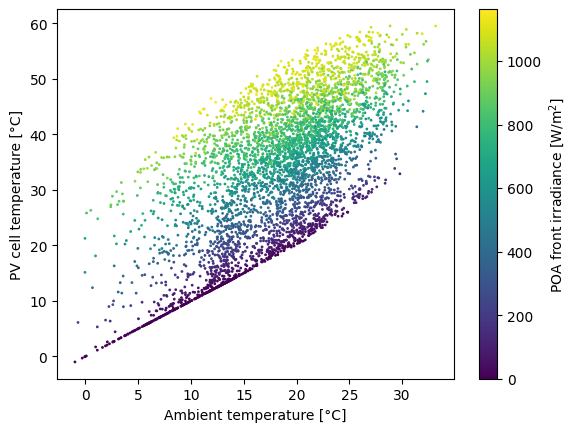

In [21]:
plt.scatter(x=data['temp_air'], y=cell_temperature, s=1, c=poa_irradiance['poa_front'])
plt.xlabel('Ambient temperature [°C]')
plt.ylabel('PV cell temperature [°C]')
plt.colorbar(label='POA front irradiance [W/m$^2$]')
plt.show()

## Step 7: Calculate DC PV power

With the plane of array irradiance and cell temperature ready, we can now estimate the PV output power. There are several modeling approaches available here, including:

* Simple efficiency (like in PVWatts)
* Single-diode models, like in PVsyst and SAM
* Empirical methods like the SAPM

Each type of these PV models requires different types of parameters.  They all produce estimates of the maximum power point (MPP), while the more complex ones also estimate other quantities like open circuit voltage and short circuit current.

👉 The simplest option is to use ``pvlib.pvsystem.pvwatts_dc`` ([link to documentation](https://pvlib-python.readthedocs.io/en/latest/reference/generated/pvlib.pvsystem.pvwatts_dc.html)). Can you use it with the POA irradiance and cell temperature to estimate the output power for all of the modules?

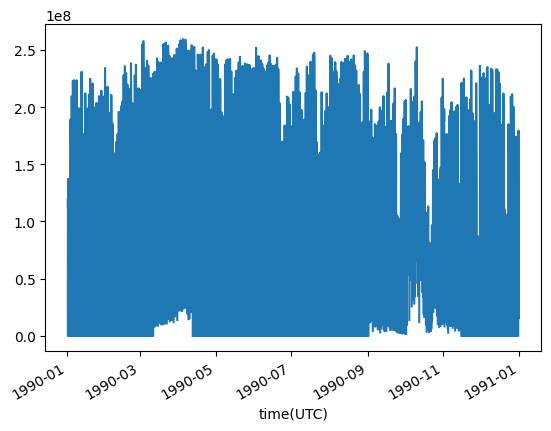

In [ ]:
pdc0_module =   # [W] Nominal power at STC
no_panels = 
pdc0 = pdc0_module * no_panels  # [W] Nominal power at STC for all panels

gamma_pdc = -0.0029 # [1/°C] Pmax temperature coefficient (look at the datasheet, but divide by 100!)

# Write your code here to calculate PV power
dc_power = pvlib.pvsystem.pvwatts_dc(

)

dc_power.plot(); # plot results

## Step 8: Reflect on the exercise

We managed to model the output of one panel, how do you think we can extend the model workflow to simulate a full system?

👉 Last, this exercise made a number of simplifications. Can you name some? How do you think the accuracy was affected?

[![Creative Commons License](https://i.creativecommons.org/l/by/4.0/88x31.png)](http://creativecommons.org/licenses/by/4.0/)

This work is licensed under a [Creative Commons Attribution 4.0 International License](http://creativecommons.org/licenses/by/4.0/).